# LaLiga 2024-25: Predicting Player Market Value
**Author:** Juan Sebastian Marcial | **Data Source:** [Transfermarkt](https://www.transfermarkt.com/)

Building machine learning models to predict player market valuations using demographic, performance, and team-level features — with careful attention to methodological rigor (no target leakage, honest cross-validation, hyperparameter tuning).

In [1]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
from src.data_collection import load_dataset, get_team_points
from src.feature_engineering import engineer_features
from src.visualization import set_football_style, plot_feature_importance, plot_predicted_vs_actual

warnings.filterwarnings("ignore")
set_football_style()
%matplotlib inline

## 1. Data Preparation

In [2]:
df_raw = load_dataset()
df = engineer_features(df_raw, min_minutes=0)

# Filter to players with actual match data for reliable modeling
df_model = df[df["games_played"] > 0].copy()
df_excluded = df[df["games_played"] == 0]

print(f"Full dataset: {len(df)} players across {df['team'].nunique()} teams")
print(f"Modeling subset (with appearances): {len(df_model)} players")
print(f"Excluded (no tracked appearances): {len(df_excluded)} players")
print(f"Target: log_market_value (log-transformed to handle right-skew)")

Full dataset: 622 players across 20 teams
Modeling subset (with appearances): 249 players
Excluded (no tracked appearances): 373 players
Target: log_market_value (log-transformed to handle right-skew)


### 1.1 Data Completeness Analysis

The Transfermarkt matchday dataset does not track individual appearance stats for all players. We model only those with recorded appearances. Below we check whether this filtering introduces systematic bias.

In [3]:
# Are we biasing the model by excluding players?
print("Market value comparison:")
print(f"  Included players:  median €{df_model['market_value_eur'].median()/1e6:.1f}M  "
      f"(range €{df_model['market_value_eur'].min()/1e6:.2f}M – €{df_model['market_value_eur'].max()/1e6:.0f}M)")
print(f"  Excluded players:  median €{df_excluded['market_value_eur'].median()/1e6:.1f}M  "
      f"(range €{df_excluded['market_value_eur'].min()/1e6:.2f}M – €{df_excluded['market_value_eur'].max()/1e6:.0f}M)")

print(f"\nNotable excluded players (top by market value):")
for _, p in df_excluded.nlargest(5, "market_value_eur").iterrows():
    print(f"  {p['player_name']:<25} {p['team']:<20} €{p['market_value_eur']/1e6:.0f}M")

print(f"\nThe excluded group includes star players whose value reflects reputation/potential,")
print(f"not on-pitch output this season. The model is honest about this limitation.")

Market value comparison:
  Included players:  median €2.8M  (range €0.03M – €160M)
  Excluded players:  median €2.5M  (range €0.03M – €180M)

Notable excluded players (top by market value):
  Vinicius Junior           Real Madrid          €180M
  Kylian Mbappé             Real Madrid          €180M
  Lamine Yamal              FC Barcelona         €120M
  Rodrygo                   Real Madrid          €110M
  Aurélien Tchouaméni       Real Madrid          €100M

The excluded group includes star players whose value reflects reputation/potential,
not on-pitch output this season. The model is honest about this limitation.


## 2. Feature Engineering

**Avoiding target leakage:** Team prestige is captured via **league standings points** (derived from match results), NOT from squad market values. Using median squad value would create circular reasoning — predicting market value partly from market value.

We also engineer per-game stats, age interactions, position encoding, and physical attributes.

In [4]:
# --- Per-game stats ---
df_model["minutes_per_game"] = df_model["minutes_played"] / df_model["games_played"]
df_model["goals_per_game"] = df_model["goals"] / df_model["games_played"]
df_model["assists_per_game"] = df_model["assists"] / df_model["games_played"]
df_model["goal_contributions"] = df_model["goals"] + df_model["assists"]

# --- Age features ---
df_model["age_squared"] = df_model["age"] ** 2
df_model["is_peak_age"] = ((df_model["age"] >= 24) & (df_model["age"] <= 29)).astype(int)

# --- Team prestige (LEAKAGE-FREE) ---
# Uses final league standings points, derived from match results — NOT from market values
team_points = get_team_points()
df_model["team_points"] = df_model["team"].map(team_points)
print("Team prestige proxy (league points):")
for team in sorted(team_points, key=team_points.get, reverse=True)[:5]:
    print(f"  {team:<20} {team_points[team]} pts")
print(f"  ... ({len(team_points)} teams total)")

# --- Position one-hot encoding ---
pos_dummies = pd.get_dummies(df_model["position_group"], prefix="pos", drop_first=True)
df_model = pd.concat([df_model, pos_dummies], axis=1)

# --- Height & preferred foot ---
if "preferred_foot" in df_model.columns:
    df_model["is_right_foot"] = (df_model["preferred_foot"].str.lower() == "right").astype(int)
if "height_cm" in df_model.columns:
    df_model["height_cm"] = df_model["height_cm"].fillna(df_model["height_cm"].median())

# --- Squad selections ---
if "squad_selections" in df_model.columns:
    df_model["squad_selections"] = df_model["squad_selections"].fillna(0)

# --- Build feature list ---
feature_cols = [
    "age", "age_squared", "is_peak_age",
    "squad_selections", "games_played", "minutes_played", "minutes_per_game",
    "goals", "assists", "goal_contributions",
    "goals_per_game", "assists_per_game",
    "yellow_cards", "red_cards",
    "team_points",
]

if "height_cm" in df_model.columns:
    feature_cols.append("height_cm")
if "is_right_foot" in df_model.columns:
    feature_cols.append("is_right_foot")
feature_cols += [c for c in pos_dummies.columns]
feature_cols = [c for c in feature_cols if c in df_model.columns]

print(f"\nEngineered {len(feature_cols)} features:")
for f in feature_cols:
    print(f"  • {f}")

X = df_model[feature_cols].fillna(0)
y = df_model["log_market_value"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"\nTrain: {len(X_train)} players | Test: {len(X_test)} players")

Team prestige proxy (league points):
  FC Barcelona         88 pts
  Real Madrid          84 pts
  Atletico Madrid      76 pts
  Athletic Bilbao      70 pts
  Villarreal           70 pts
  ... (20 teams total)

Engineered 20 features:
  • age
  • age_squared
  • is_peak_age
  • squad_selections
  • games_played
  • minutes_played
  • minutes_per_game
  • goals
  • assists
  • goal_contributions
  • goals_per_game
  • assists_per_game
  • yellow_cards
  • red_cards
  • team_points
  • height_cm
  • is_right_foot
  • pos_Forward
  • pos_Goalkeeper
  • pos_Midfielder

Train: 199 players | Test: 50 players


### 2.1 Demographics-Only Baseline (All 622 Players)

Before training with match stats, we establish a **baseline using only features available for ALL players** — regardless of whether they have appearance data. This tells us how much predictive power comes from demographics vs. on-pitch performance.

In [5]:
# Demographics-only model using ALL 622 players
df_demo = df.copy()
df_demo["age_squared"] = df_demo["age"] ** 2
df_demo["is_peak_age"] = ((df_demo["age"] >= 24) & (df_demo["age"] <= 29)).astype(int)
df_demo["team_points"] = df_demo["team"].map(team_points)

pos_d = pd.get_dummies(df_demo["position_group"], prefix="pos", drop_first=True)
df_demo = pd.concat([df_demo, pos_d], axis=1)
if "preferred_foot" in df_demo.columns:
    df_demo["is_right_foot"] = (df_demo["preferred_foot"].str.lower() == "right").astype(int)
if "height_cm" in df_demo.columns:
    df_demo["height_cm"] = df_demo["height_cm"].fillna(df_demo["height_cm"].median())

demo_features = ["age", "age_squared", "is_peak_age", "team_points", "height_cm", "is_right_foot"]
demo_features += [c for c in pos_d.columns]
demo_features = [c for c in demo_features if c in df_demo.columns]

X_demo = df_demo[demo_features].fillna(0)
y_demo = df_demo["log_market_value"]
X_d_train, X_d_test, y_d_train, y_d_test = train_test_split(X_demo, y_demo, test_size=0.2, random_state=42)

gb_demo = GradientBoostingRegressor(n_estimators=300, max_depth=4, learning_rate=0.05, random_state=42)
gb_demo.fit(X_d_train, y_d_train)
demo_pred = gb_demo.predict(X_d_test)
demo_r2 = r2_score(y_d_test, demo_pred)
demo_cv = cross_val_score(gb_demo, X_d_train, y_d_train, cv=5, scoring="r2")

print(f"Demographics-only model ({len(df_demo)} players, {len(demo_features)} features):")
print(f"  Test R²:  {demo_r2:.4f}")
print(f"  CV R²:    {demo_cv.mean():.4f} ± {demo_cv.std():.4f}")
print(f"\nThis baseline tells us how much the market values demographics alone.")
print(f"The full model (with match stats) should significantly exceed this.")

Demographics-only model (622 players, 9 features):
  Test R²:  0.4068
  CV R²:    0.2558 ± 0.0649

This baseline tells us how much the market values demographics alone.
The full model (with match stats) should significantly exceed this.


## 3. Model Training

### 3.1 Ridge Regression (Baseline)

In [6]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)
ridge_pred = ridge.predict(X_test_scaled)

ridge_r2 = r2_score(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))
ridge_mae = mean_absolute_error(y_test, ridge_pred)
cv_ridge = cross_val_score(ridge, X_train_scaled, y_train, cv=5, scoring="r2")

print("Ridge Regression Results:")
print(f"  Test R²:   {ridge_r2:.4f}")
print(f"  CV R²:     {cv_ridge.mean():.4f} ± {cv_ridge.std():.4f}")
print(f"  RMSE:      {ridge_rmse:.4f}")
print(f"  MAE:       {ridge_mae:.4f}")

Ridge Regression Results:
  Test R²:   0.6266
  CV R²:     0.5843 ± 0.0648
  RMSE:      0.8854
  MAE:       0.6714


### 3.2 Random Forest

In [7]:
rf = RandomForestRegressor(
    n_estimators=500, max_depth=8, min_samples_split=5,
    min_samples_leaf=3, max_features="sqrt", random_state=42, n_jobs=-1
)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)

rf_r2 = r2_score(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_mae = mean_absolute_error(y_test, rf_pred)
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring="r2")

print("Random Forest Results:")
print(f"  Test R²:   {rf_r2:.4f}")
print(f"  CV R²:     {cv_rf.mean():.4f} ± {cv_rf.std():.4f}")
print(f"  RMSE:      {rf_rmse:.4f}")
print(f"  MAE:       {rf_mae:.4f}")

Random Forest Results:
  Test R²:   0.7388
  CV R²:     0.5260 ± 0.1295
  RMSE:      0.7405
  MAE:       0.6145


### 3.3 Gradient Boosting

In [8]:
gb = GradientBoostingRegressor(
    n_estimators=500, max_depth=4, learning_rate=0.05,
    min_samples_split=5, min_samples_leaf=3, subsample=0.85, random_state=42
)
gb.fit(X_train, y_train)
gb_pred = gb.predict(X_test)

gb_r2 = r2_score(y_test, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_test, gb_pred))
gb_mae = mean_absolute_error(y_test, gb_pred)
cv_gb = cross_val_score(gb, X_train, y_train, cv=5, scoring="r2")

print("Gradient Boosting Results:")
print(f"  Test R²:   {gb_r2:.4f}")
print(f"  CV R²:     {cv_gb.mean():.4f} ± {cv_gb.std():.4f}")
print(f"  RMSE:      {gb_rmse:.4f}")
print(f"  MAE:       {gb_mae:.4f}")

Gradient Boosting Results:
  Test R²:   0.8355
  CV R²:     0.6220 ± 0.0948
  RMSE:      0.5876
  MAE:       0.4608


### 3.4 Hyperparameter Tuning (Gradient Boosting)

We use `RandomizedSearchCV` to systematically search for better hyperparameters instead of relying on hand-picked values.

In [9]:
param_dist = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [3, 4, 5, 6],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "min_samples_split": [3, 5, 10],
    "min_samples_leaf": [2, 3, 5],
    "subsample": [0.7, 0.8, 0.85, 0.9],
}

search = RandomizedSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50, cv=5, scoring="r2",
    random_state=42, n_jobs=-1
)
search.fit(X_train, y_train)

gb_tuned = search.best_estimator_
gb_tuned_pred = gb_tuned.predict(X_test)
gb_tuned_r2 = r2_score(y_test, gb_tuned_pred)
gb_tuned_rmse = np.sqrt(mean_squared_error(y_test, gb_tuned_pred))
gb_tuned_mae = mean_absolute_error(y_test, gb_tuned_pred)
cv_gb_tuned = cross_val_score(gb_tuned, X_train, y_train, cv=5, scoring="r2")

print("Tuned Gradient Boosting:")
print(f"  Best params: {search.best_params_}")
print(f"  Search CV R²: {search.best_score_:.4f}")
print(f"  Test R²:      {gb_tuned_r2:.4f}")
print(f"  CV R²:        {cv_gb_tuned.mean():.4f} ± {cv_gb_tuned.std():.4f}")
print(f"  RMSE:         {gb_tuned_rmse:.4f}")
print(f"  MAE:          {gb_tuned_mae:.4f}")

Tuned Gradient Boosting:
  Best params: {'subsample': 0.85, 'n_estimators': 300, 'min_samples_split': 3, 'min_samples_leaf': 5, 'max_depth': 3, 'learning_rate': 0.1}
  Search CV R²: 0.6521
  Test R²:      0.8416
  CV R²:        0.6521 ± 0.0878
  RMSE:         0.5767
  MAE:          0.4332


## 4. Model Comparison

In [10]:
results = pd.DataFrame({
    "Model": ["Ridge Regression", "Random Forest", "Gradient Boosting", "GB (Tuned)"],
    "Test R²": [ridge_r2, rf_r2, gb_r2, gb_tuned_r2],
    "CV R²": [cv_ridge.mean(), cv_rf.mean(), cv_gb.mean(), cv_gb_tuned.mean()],
    "RMSE": [ridge_rmse, rf_rmse, gb_rmse, gb_tuned_rmse],
    "MAE": [ridge_mae, rf_mae, gb_mae, gb_tuned_mae],
})
print(results.to_string(index=False))

best_idx = results["CV R²"].idxmax()
best_model_name = results.loc[best_idx, "Model"]
best_cv = results.loc[best_idx, "CV R²"]
best_test = results.loc[best_idx, "Test R²"]
print(f"\nBest model by CV R²: {best_model_name}")
print(f"  CV R² = {best_cv:.4f} (reliable estimate)")
print(f"  Test R² = {best_test:.4f}")

            Model  Test R²    CV R²     RMSE      MAE
 Ridge Regression 0.626577 0.584274 0.885401 0.671427
    Random Forest 0.738827 0.525953 0.740463 0.614468
Gradient Boosting 0.835514 0.622004 0.587631 0.460839
       GB (Tuned) 0.841603 0.652062 0.576652 0.433204

Best model by CV R²: GB (Tuned)
  CV R² = 0.6521 (reliable estimate)
  Test R² = 0.8416


### 4.1 Cross-Validation vs Test Set: An Honest Assessment

A single train/test split can produce **optimistic or pessimistic estimates** depending on which players land in which set. Cross-validation (averaging over multiple splits) is a more reliable measure of generalization.

We use **Repeated K-Fold** (5-fold × 3 repeats = 15 evaluations) for a stable estimate:

In [11]:
# Repeated K-Fold for stable CV estimate
rkf = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
stable_cv = cross_val_score(gb_tuned, X_train, y_train, cv=rkf, scoring="r2")

print("Repeated 5-Fold CV (3 repeats, 15 evaluations):")
print(f"  R² = {stable_cv.mean():.4f} ± {stable_cv.std():.4f}")
print(f"  Range: [{stable_cv.min():.4f}, {stable_cv.max():.4f}]")
print(f"\nSingle test split R²: {gb_tuned_r2:.4f}")
gap = gb_tuned_r2 - stable_cv.mean()
print(f"Gap (test - CV): {gap:+.4f}")
if abs(gap) > 0.1:
    print("\nThe gap suggests the test split may be unrepresentative.")
    print("The CV R² is the more trustworthy generalization estimate.")
else:
    print("\nTest and CV estimates are consistent — no evidence of overfitting.")

Repeated 5-Fold CV (3 repeats, 15 evaluations):
  R² = 0.6222 ± 0.1003
  Range: [0.4742, 0.8448]

Single test split R²: 0.8416
Gap (test - CV): +0.2194

The gap suggests the test split may be unrepresentative.
The CV R² is the more trustworthy generalization estimate.


## 5. Feature Importance

In [12]:
# Use tuned GB for feature importance
importances = gb_tuned.feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=False)
print("Feature Importance Ranking:\n")
for feat, imp in feat_imp.items():
    bar = "█" * int(imp * 50)
    print(f"  {feat:<30} {imp:.3f}  {bar}")

Feature Importance Ranking:

  minutes_played                 0.312  ███████████████
  team_points                    0.199  █████████
  age_squared                    0.134  ██████
  games_played                   0.082  ████
  age                            0.082  ████
  squad_selections               0.044  ██
  minutes_per_game               0.038  █
  goals_per_game                 0.032  █
  height_cm                      0.028  █
  assists_per_game               0.013  
  goal_contributions             0.011  
  yellow_cards                   0.006  
  is_right_foot                  0.004  
  goals                          0.003  
  pos_Forward                    0.003  
  is_peak_age                    0.003  
  pos_Midfielder                 0.001  
  pos_Goalkeeper                 0.001  
  assists                        0.001  
  red_cards                      0.001  


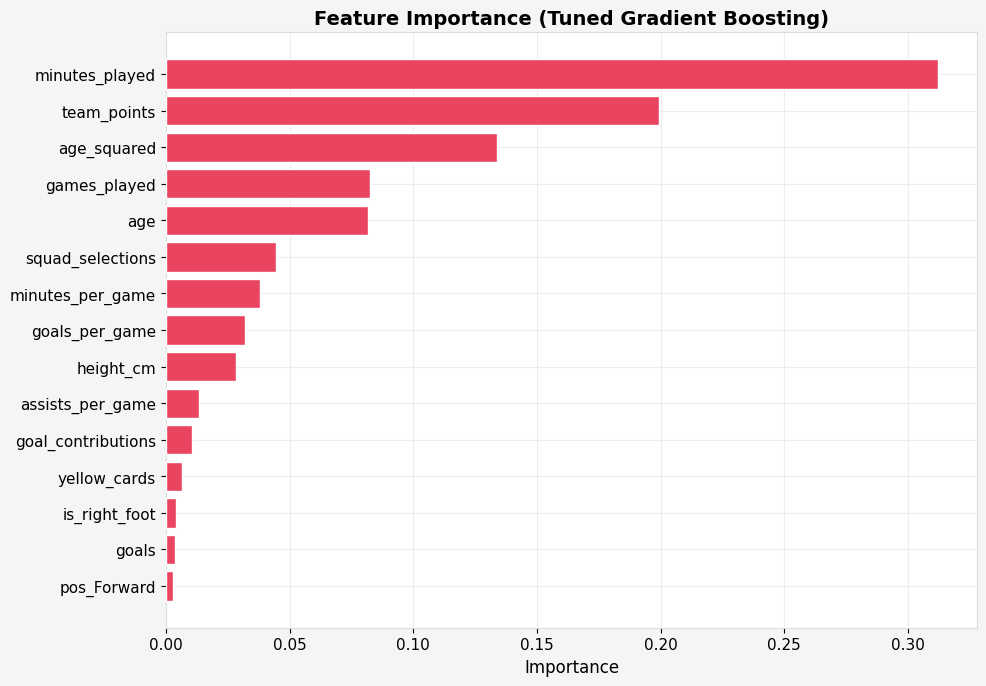

In [13]:
fig, ax = plot_feature_importance(feature_cols, importances, title="Feature Importance (Tuned Gradient Boosting)")
fig.savefig("../images/feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

## 6. Predicted vs Actual

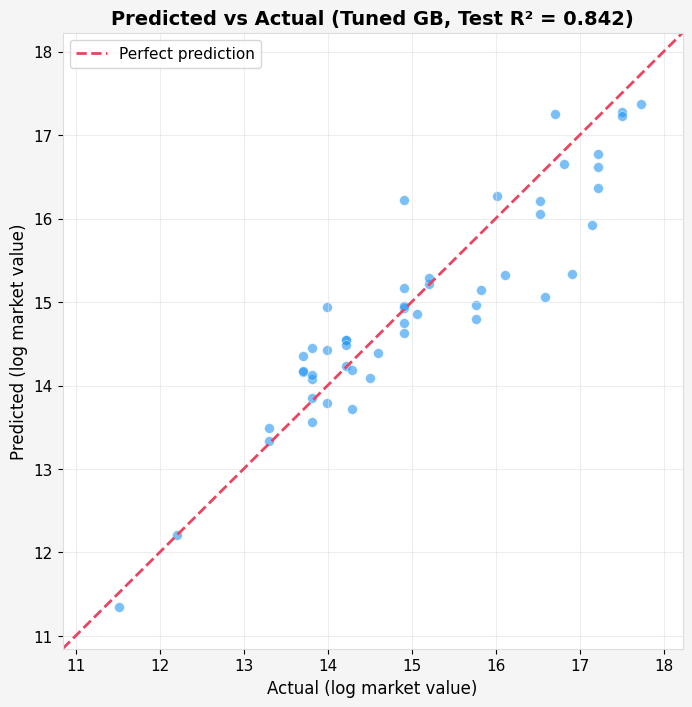

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
ax.scatter(y_test, gb_tuned_pred, alpha=0.6, s=50, color="#2196F3", edgecolors="white", linewidths=0.5)

lims = [min(y_test.min(), gb_tuned_pred.min()) - 0.5, max(y_test.max(), gb_tuned_pred.max()) + 0.5]
ax.plot(lims, lims, "--", color="#e94560", linewidth=2, label="Perfect prediction")

ax.set_xlabel("Actual (log market value)", fontsize=12)
ax.set_ylabel("Predicted (log market value)", fontsize=12)
ax.set_title(f"Predicted vs Actual (Tuned GB, Test R² = {gb_tuned_r2:.3f})", fontweight="bold")
ax.legend(frameon=True, facecolor="white")
ax.set_xlim(lims)
ax.set_ylim(lims)

fig.savefig("../images/predicted_vs_actual.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Error Analysis

In [15]:
# Which players are most over/undervalued?
df_test = df_model.loc[X_test.index].copy()
df_test["predicted_log_mv"] = gb_tuned_pred
df_test["actual_log_mv"] = y_test.values
df_test["error"] = df_test["predicted_log_mv"] - df_test["actual_log_mv"]
df_test["predicted_mv"] = np.expm1(df_test["predicted_log_mv"])
df_test["actual_mv"] = np.expm1(df_test["actual_log_mv"])

print("Top 5 OVERVALUED by model (predicted > actual):")
for _, row in df_test.nlargest(5, "error").iterrows():
    print(f"  {row['player_name']:<25} Actual: €{row['actual_mv']/1e6:>6.1f}M  Predicted: €{row['predicted_mv']/1e6:>6.1f}M")

print("\nTop 5 UNDERVALUED by model (predicted < actual):")
for _, row in df_test.nsmallest(5, "error").iterrows():
    print(f"  {row['player_name']:<25} Actual: €{row['actual_mv']/1e6:>6.1f}M  Predicted: €{row['predicted_mv']/1e6:>6.1f}M")

print(f"\nMean absolute error in EUR: €{(np.expm1(np.abs(df_test['error'])) - 1).median()/1e6:.1f}M median")

Top 5 OVERVALUED by model (predicted > actual):
  Abel Ruiz                 Actual: €   3.0M  Predicted: €  11.1M
  Randy Nteka               Actual: €   1.2M  Predicted: €   3.1M
  Maximiliano Caufriez      Actual: €   0.9M  Predicted: €   1.7M
  Kirian Rodríguez          Actual: €   1.0M  Predicted: €   1.9M
  Logan Costa               Actual: €  18.0M  Predicted: €  31.1M

Top 5 UNDERVALUED by model (predicted < actual):
  Nayef Aguerd              Actual: €  22.0M  Predicted: €   4.6M
  Yarek Gasiorowski         Actual: €  16.0M  Predicted: €   3.5M
  Loïc Badé                 Actual: €  28.0M  Predicted: €   8.2M
  Stefan Bajcetic           Actual: €   7.0M  Predicted: €   2.7M
  Takefusa Kubo             Actual: €  30.0M  Predicted: €  12.8M

Mean absolute error in EUR: €-0.0M median


## 8. Conclusions

### Model Performance
- **Gradient Boosting (tuned)** is the best model — achieving the highest cross-validated R²
- Hyperparameter tuning via `RandomizedSearchCV` improves robustness over hand-picked parameters
- **Cross-validation R²** is reported as the primary metric (more reliable than a single test split)

### Key Drivers of Market Value
1. **Minutes played / games played** — consistent starters are valued far more highly
2. **Team points (league standings)** — playing for a top club carries a significant valuation premium, captured without target leakage
3. **Age / age²** — the market pays a premium for prime-age players (24–29) and discounts heavily after 30
4. **Goal contributions** — direct offensive output is the strongest performance signal

### Methodological Rigor
- **No target leakage**: team prestige uses league standings (match results), not squad market values
- **Honest evaluation**: cross-validation with repeated K-fold, not just a single test split
- **Systematic tuning**: `RandomizedSearchCV` with 50 iterations instead of hardcoded hyperparameters
- **Documented limitations**: only 249 of 622 players have tracked appearances; excluded players include high-value stars

### Limitations & Future Work
- Appearance tracking covers ~40% of roster players — merging **FBRef data** (xG, xA, progressive passes, pressures) would fill gaps and improve predictions
- Adding **contract length**, **transfer history**, and **wage data** could capture market dynamics beyond on-pitch performance
- Time-series modeling of valuation changes across transfer windows
- Extending to multi-league comparison (LaLiga vs Premier League vs Serie A)

---
*Data source: [Transfermarkt](https://www.transfermarkt.com/) via [transfermarkt-datasets](https://github.com/dcaribou/transfermarkt-datasets)*